In [92]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [93]:
df_index =pd.read_csv('readd.csv')

In [94]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [95]:
#drop unnesscary 
df_index.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [96]:
#check null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

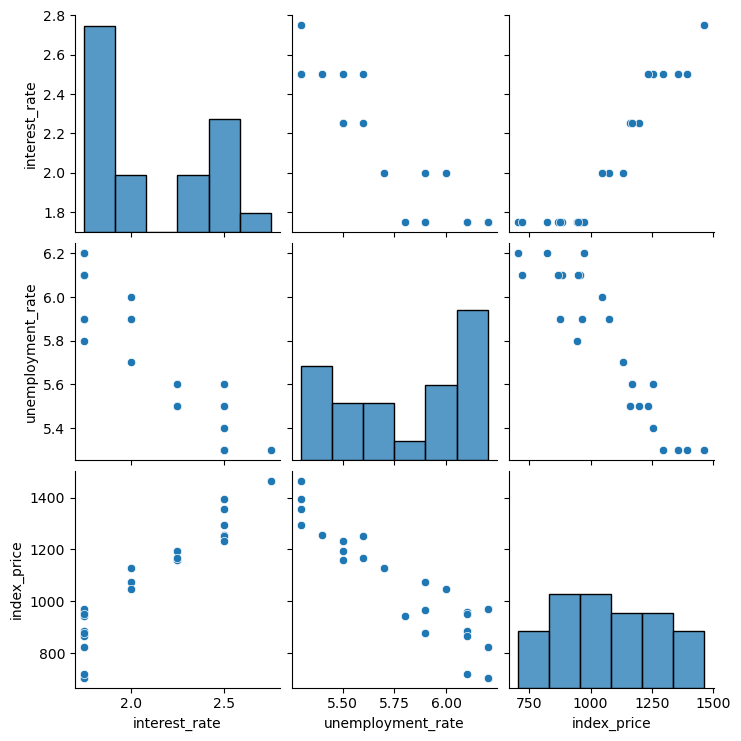

In [97]:
import seaborn as sns
sns.pairplot(df_index)

In [98]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'unemployment_rate')

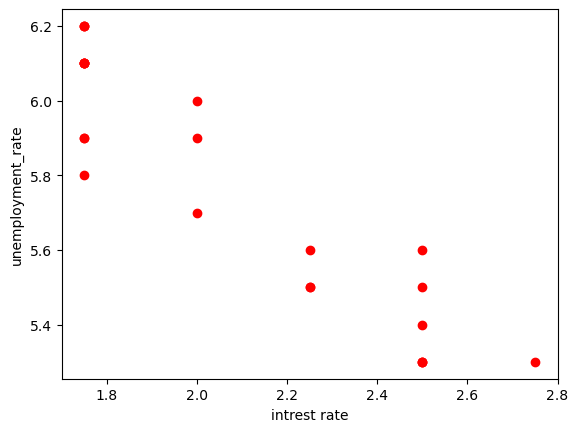

In [99]:
#more visuals
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='red')
plt.xlabel('intrest rate')
plt.ylabel('unemployment_rate')

In [100]:
#independent and dependent features
x=df_index.iloc[:,:-1]
y=df_index.iloc[:,-1]

In [101]:
x.head()


,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [102]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

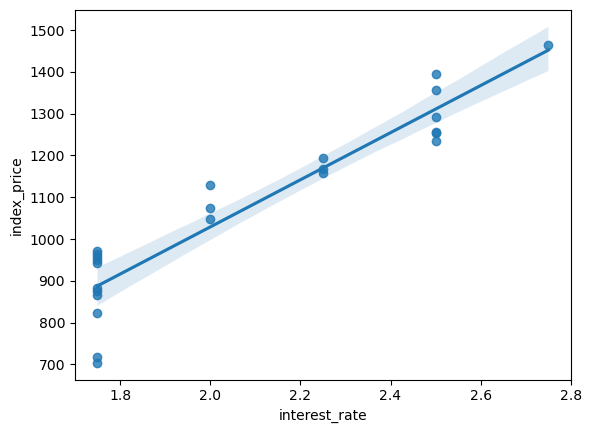

In [103]:
import seaborn as sns

sns.regplot(x=df_index['interest_rate'], y=df_index['index_price'])

In [104]:
#standardization
from sklearn.preprocessing import StandardScaler

In [105]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [106]:
x_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [107]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [108]:
regression.coef_


array([  88.27275507, -116.25716066])

In [109]:
regression.intercept_

np.float64(1053.4444444444443)

In [110]:
from sklearn.model_selection import cross_val_score

In [111]:
validation_score=cross_val_score(regression,x_train,y_train,scoring='neg_mean_squared_error',cv=3)

In [112]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [113]:
#for getting its average
np.mean(validation_score)

np.float64(-5914.828180162395)

In [114]:
#prediction
y_pred=regression.predict(x_test)
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [115]:
#performance metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [116]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

8108.567426306604
73.80444932337097
90.04758423359621


In [117]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.7591371539010257


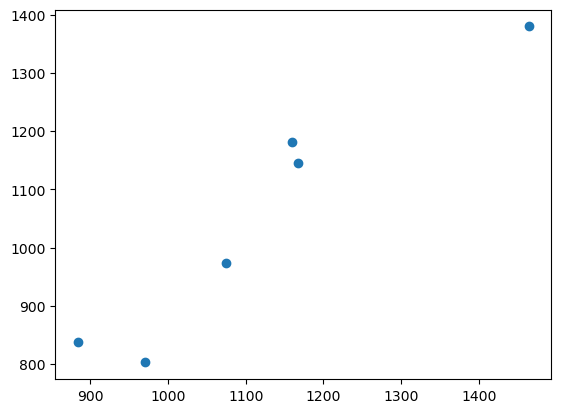

In [118]:
#assumptions
plt.scatter(y_test,y_pred)

In [119]:
residuals=y_test-y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


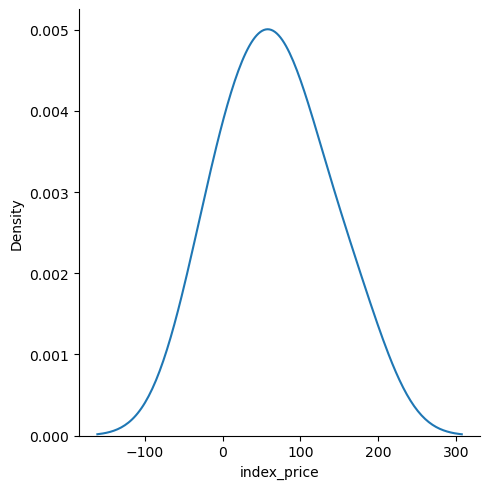

In [120]:
sns.displot(residuals,kind='kde')

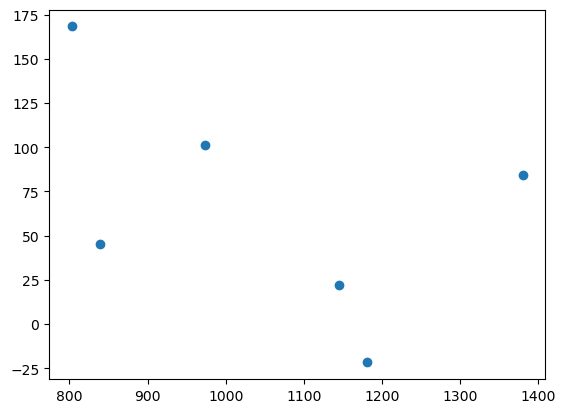

In [121]:
plt.scatter(y_pred,residuals)

In [122]:
#ols
import statsmodels.api as sm

In [123]:
model=sm.OLS(y_train,x_train).fit()
prediction=model.predict(x_train)
print(prediction)

[-123.61879426  287.98428644 -231.79392541  179.80915529  287.98428644
  -94.59289851 -195.73554836  287.98428644  251.92590939 -231.79392541
 -195.73554836 -123.61879426 -195.73554836  150.78325954   13.58223264
  -87.56041721 -195.73554836  215.86753234]


In [124]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 20 Sep 2026   Prob (F-statistic):                       0.754
Time:                        20:00:13   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------